# Google Colab Setup 

Please run the code below to mount drive if you are running on colab.

Please ignore if you are running on your local machine.

In [1]:
# from google.colab import drive
# drive.mount('/content/drive')

In [2]:
# %cd /content/drive/MyDrive/MiniGPT/

In [3]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "3"
os.environ["WANDB_MODE"] = "disabled"
import warnings
warnings.filterwarnings("ignore")

# Now import torch (only AFTER setting env vars)
import torch
print("CUDA available:", torch.cuda.is_available())
print("Device count:", torch.cuda.device_count())
if torch.cuda.is_available():
    print("Device name:", torch.cuda.get_device_name(0))

CUDA available: True
Device count: 1
Device name: NVIDIA RTX A6000


# Language Modeling and Transformers

The project will consist of two broad parts. 

1. **Baseline Generative Language Model**: We will train a simple Bigram language model on the text data. We will use this model to generate a mini story. 
2. **Implementing Mini GPT**: We will implement a mini version of the GPT model layer by layer and attempt to train it on the text data. You will then load pretrained weights provided and generate a mini story. 

## Some general instructions 

1. Please keep the name of layers consistent with what is requested in the `model.py` file for each layer, this helps us test in each function independently. 
2. Please check to see if the bias is to be set to false or true for all linear layers (it is mentioned in the doc string)
3. As a general rule please read the docstring well, it contains information you will need to write the code. 
4. All configs are defined in `config.py` for the first part. While you are writing the code, do not change the values in the config file since we use them to test. Once you have passed all the tests please feel free to vary the parameter as you please.
5. You will need to fill in `train.py` and run it to train the model. If you are running into memory issues please feel free to change the `batch_size` in the `config.py` file. If you are working on Colab please make sure to use the GPU runtime and feel free to copy over the training code to the notebook. 

In [4]:
!pip install numpy torch tiktoken wandb einops # Install all required packages

In [5]:
%load_ext autoreload
%autoreload 2

In [6]:
import torch
import tiktoken

In [7]:
from model import BigramLanguageModel, SingleHeadAttention, MultiHeadAttention, FeedForwardLayer, LayerNorm, TransformerLayer, MiniGPT
from config import BigramConfig, MiniGPTConfig
import tests

In [8]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [9]:
# If not provided, download from https://drive.google.com/file/d/1g09qUM9WibdfQVgkj6IAj8K2S3SGwc91/view?usp=sharing
path_to_bigram_tester = "./pretrained_models/bigram_tester.pt" # Load the bigram model with name bigram_tester.pt
path_to_gpt_tester = "./pretrained_models/minigpt_tester.pt" # Load the gpt model with name minigpt_tester.pt

##  Bigram Language Model (10 points)

A bigram language model is a type of probabilistic language model that predicts a word given the previous word in the sequence. The model is trained on a text corpus and learns the probability of a word given the previous word.



### Implement the Bigram model (5 points)

Please complete the `BigramLanguageModel` class in model.py. We will model a Bigram language model using a simple MLP with one hidden layer. The model will take in the previous word index and output the logits over the vocabulary for the next word.

In [10]:
# Test implementation for Bigram Language Model
model = BigramLanguageModel(BigramConfig)
tests.check_bigram(model, path_to_bigram_tester, device)

'TEST CASE PASSED!!!'

### Training the Bigram Language Model (2.5 points)

Complete the code in `train.py` to train the Bigram language model on the text data. Please provide plots for both the training and validation in the cell below.

Some notes on the training process:

1. You should be able to train the model slowly on your local machine.
2. Training it on Colab will help with speed.
3.  <span style="color:red">To get full points for this section it is sufficient to show that the loss is decreasing over time</span>. You should see it saturate to a value close to around 5-6 but as long as you see it decreasing then saturating you should be good.
4. Please log the loss curves either on wandb, tensorboard or any other logger of your choice and please attach them below.

In [11]:
from train import solver

In [12]:
# solver(model_name="bigram")

# Train the bigram model. We patch print() to harvest loss values for plotting,
# while keeping the training script itself untouched.
import re, builtins
losses_bi = {"iter": [], "train": [], "eval": []}
_orig_print = builtins.print
def _capture(*args, **kwargs):
    s = " ".join(str(a) for a in args)
    m = re.search(r"Iteration (\d+).*Train Loss: ([\d.]+).*Eval Loss: ([\d.]+)", s)
    if m:
        losses_bi["iter"].append(int(m.group(1)))
        losses_bi["train"].append(float(m.group(2)))
        losses_bi["eval"].append(float(m.group(3)))
    _orig_print(*args, **kwargs)
builtins.print = _capture
try:
    solver(model_name="bigram")
finally:
    builtins.print = _orig_print
print(f"Logged {len(losses_bi['iter'])} loss points.")

number of trainable parameters: 3.27M
Iteration 0, Train Loss: 10.824918746948242 Eval Loss: 10.824890422821046
Iteration 1000, Train Loss: 10.516986846923828 Eval Loss: 10.523690938949585
Iteration 2000, Train Loss: 9.573844909667969 Eval Loss: 9.70582537651062
Iteration 3000, Train Loss: 8.80283260345459 Eval Loss: 8.67628846168518
Iteration 4000, Train Loss: 8.293472290039062 Eval Loss: 7.920328593254089
Iteration 5000, Train Loss: 7.626105308532715 Eval Loss: 7.5652202606201175
Iteration 6000, Train Loss: 7.656124114990234 Eval Loss: 7.1183552026748655
Iteration 7000, Train Loss: 7.314387321472168 Eval Loss: 6.934261202812195
Iteration 8000, Train Loss: 7.00661039352417 Eval Loss: 6.7972681522369385
Iteration 9000, Train Loss: 6.182981967926025 Eval Loss: 6.597732090950013
Iteration 10000, Train Loss: 6.4697957038879395 Eval Loss: 6.50149097442627
Iteration 11000, Train Loss: 6.245934009552002 Eval Loss: 6.333002758026123
Iteration 12000, Train Loss: 6.464695453643799 Eval Loss: 6.

### Train and Valid Plots


** Show the training and validation loss plots **

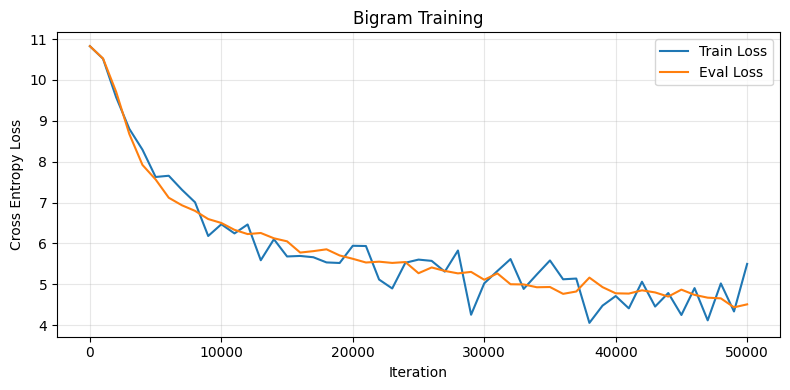

In [13]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 4))
plt.plot(losses_bi["iter"], losses_bi["train"], label="Train Loss")
plt.plot(losses_bi["iter"], losses_bi["eval"], label="Eval Loss")
plt.xlabel("Iteration"); plt.ylabel("Cross Entropy Loss")
plt.title("Bigram Training"); plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("bigram_loss.png", dpi=120)
plt.show()

### Generation (2.5 points)

Complete the code in the `generate` method of the Bigram class and generate a mini story using the trained Bigram language model. The model will take in the previous word index and output the next word index.

Start with the following seed sentence: 
    
    `"once upon a time"`
    

In [14]:
model_path = "models/bigram/mini_model_checkpoint_50000.pt"  # or whatever checkpoint you saved
# model_path = "models/bigram/best_train_loss_checkpoint.pt"

model = BigramLanguageModel(BigramConfig)
tokenizer = tiktoken.get_encoding("gpt2")
model.load_state_dict(torch.load(model_path, map_location=device)["model_state_dict"])

<All keys matched successfully>

In [15]:
model.to(device)
gen_sent = "Once upon a time"
gen_tokens = torch.tensor(tokenizer.encode(gen_sent))
print("Generating text starting with:", gen_tokens.shape)
gen_tokens = gen_tokens.to(device)
model.eval()
text = tokenizer.decode(
    model.generate(gen_tokens, max_new_tokens=200).squeeze().tolist()
)
print(text[:800])  # cap printed length to keep PDF compact

Generating text starting with: torch.Size([4])
Once upon a time, record spent everyone said, they with the penny It's dreaming stars lost. She towers care and sees. Spot that put
 shapes first the vehicle seed tide torn boring followed you he mom saw happy and and from find and thought Ben, "Hello. She dangerous feels trip.
 stepped His scared and keep more the lady. He forth beach, " trail microphone dinosaur jokes puzzles Lily was a magic gray together to rain, she liked to play. We! himself Her mom. They saw, small red crib gettingLuLily was very surprised friends. They dirt's!" must storm to their suddenly.Once upon a big ducks on a dog see a the hug. breeze Ruthilda anonymity av goose Foxroom Pars crashunny received fork didn't have to thing to pull's fun. Max wanted to read her mom strong and the protect help away. The finger y T


### Observation and Analysis

Please answer the following questions. 

1. What can we say about the generated text in terms of grammar and coherence? 
2. What are the limitations of the Bigram language model?
3. If the model is scaled with more parameters do you expect the bigram model to get substantially better? Why or why not?

### Answers:

**1. Grammar and coherence**: Adjacent token pairs sometimes look natural (e.g. "Once upon a time", "she went to") because these are common bigrams in the corpus. However the overall sentence is grammatically broken and there is no long-range coherence. Pronouns drift, characters appear out of nowhere, and clauses do not connect across more than a couple of words.

**2. Limitations of the Bigram model**:
- Markov assumption with context length 1 — all dependencies beyond the previous single token are ignored.
- No notion of position, hierarchy, or syntactic structure.
- Cannot model subject-verb agreement across clauses, pronoun resolution, or topic continuity.
- Effectively a vocab × vocab transition table, very sparse for a 50k vocab.

**3. Will scaling parameters help substantially?**: No. The bottleneck is architectural, not parametric. Adding more parameters lets the model memorize transition probabilities more sharply, but it still only sees the previous token. To get qualitatively better generation we need an architecture that attends to longer context — exactly what the Transformer provides.

## Mini GPT (90 points)

We will implement a decoder style transformer model like we discussed in lecture, which is a scaled down version of the [GPT model](https://cdn.openai.com/research-covers/language-unsupervised/language_understanding_paper.pdf). 

All the model components follow directly from the original [Attention is All You Need](https://arxiv.org/abs/1706.03762) paper. The only difference is we will use prenormalization and learnt positional embeddings instead of fixed ones.

We will now implement each layer step by step checking if it is implemented correctly in the process. We will finally put together all our layers to get a fully fledged GPT model. 

<span style="color:red">Later layers might depend on previous layers so please make sure to check the previous layers before moving on to the next one.</span>

### Single Head Causal Attention (20 points)

We will first implement the single head causal attention layer. This layer is the same as the scaled dot product attention layer but with a causal mask to prevent the model from looking into the future.

Recall that Each head has a Key, Query and Value Matrix and the scaled dot product attention is calculated as : 

\begin{equation}
\text{Attention}(Q, K, V) = \text{softmax}\left(\frac{QK^T}{\sqrt{d_k}}\right)V
\end{equation}

where $d_k$ is the dimension of the key matrix.

Figure below from the original paper shows how the layer is to be implemented.

![image](./Images/Single_Head.png)

Image credits: [Attention is All You Need Paper](https://arxiv.org/abs/1706.03762)

Please complete the `SingleHeadAttention` class in `model.py`

In [16]:
model = SingleHeadAttention(MiniGPTConfig.embed_dim, MiniGPTConfig.embed_dim//4, MiniGPTConfig.embed_dim//4) # configs are set as such for testing do not modify
tests.check_singleheadattention(model, path_to_gpt_tester, device)

'TEST CASE PASSED!!!'

### Multi Head Attention (10 points)

Now that we have a single head working, we will now scale this across multiple heads, remember that with multihead attention we compute perform head number of parallel attention operations. We then concatenate the outputs of these parallel attention operations and project them back to the desired dimension using an output linear layer.

Figure below from the original paper shows how the layer is to be implemented.

![image](./Images/MultiHead.png)

Image credits: [Attention is All You Need Paper](https://arxiv.org/abs/1706.03762)

Please complete the `MultiHeadAttention` class in `model.py` using the `SingleHeadAttention` class implemented earlier. 

In [17]:
model = MultiHeadAttention(MiniGPTConfig.embed_dim, MiniGPTConfig.num_heads)
tests.check_multiheadattention(model, path_to_gpt_tester, device)

'TEST CASE PASSED!!!'

### Feed Forward Layer (5 points)

As discussed in lecture, the attention layer is completely linear, in order to add some non-linearity we add a feed forward layer. The feed forward layer is a simple two layer MLP with a GeLU activation in between.

Please complete the `FeedForwardLayer` class in `model.py`

In [18]:
model = FeedForwardLayer(MiniGPTConfig.embed_dim)
tests.check_feedforward(model, path_to_gpt_tester, device)

'TEST CASE PASSED!!!'

### LayerNorm (10 points)

We will now implement the layer normalization layer. Layernorm is used across the model to normalize the activations of the previous layer. Recall that the equation for layernorm is given as:

\begin{equation}

\text{LayerNorm}(x) = \frac{x - \mu}{\sqrt{\sigma^2 + \epsilon}} \odot \gamma + \beta

\end{equation}

With the learnable parameters $\gamma$ and $\beta$. 

Remember that unlike batchnorm we compute statistics across the feature dimension and not the batch dimension, hence we do not need to keep track of running averages.

Please complete the `LayerNorm` class in `model.py`

In [19]:
model = LayerNorm(MiniGPTConfig.embed_dim)
tests.check_layernorm(model, path_to_gpt_tester, device)

'TEST CASE PASSED!!!'

### Transformer Layer (15 points)

We have now implemented all the components of the transformer layer. We will now put it all together to create a transformer layer. The transformer layer consists of a multi head attention layer, a feed forward layer and two layer norm layers.

Please use the following order for each component (Varies slightly from the original attention paper):
1. LayerNorm
2. MultiHeadAttention
3. LayerNorm
4. FeedForwardLayer

Remember that the transformer layer also has residual connections around each sublayer.

The below figure shows the structure of the transformer layer you are required to implement.

![prenorm_transformer](./Images/Prenorm.png)

Image Credit : [CogView](https://arxiv.org/pdf/2105.13290)

Implement the `TransformerLayer` class in `model.py`

In [20]:
model =  TransformerLayer(MiniGPTConfig.embed_dim, MiniGPTConfig.num_heads)
tests.check_transformer(model, path_to_gpt_tester, device)

'TEST CASE PASSED!!!'

### Putting it all together : MiniGPT (15 points)

We are now ready to put all our layers together to build our own MiniGPT! 

The MiniGPT model consists of an embedding layer, a positional encoding layer and a stack of transformer layers. The output of the transformer layer is passed through a linear layer (called head) to get the final output logits. Note that in our implementation we will use [weight tying](https://arxiv.org/abs/1608.05859) between the embedding layer and the final linear layer. This allows us to save on parameters and also helps in training.

Implement the `MiniGPT` class in `model.py`

In [21]:
model = MiniGPT(MiniGPTConfig)
tests.check_miniGPT(model, path_to_gpt_tester, device)

'TEST CASE PASSED!!!'

### Attempt at training the model (5 points)

We will now attempt to train the model on the text data. We will use the same text data as before. If needed, you can scale down the model parameters in the config file to a smaller value to make training feasible. 

Use the same training script we built for the Bigram model to train the MiniGPT model. If you implemented it correctly it should work just out of the box!

**NOTE** : We will not be able to train the model to completion in this assignment. Unfortunately, without access to a relatively powerful GPU, training a large enough model to see good generation is not feasible. However, you should be able to see the loss decreasing over time. <span style="color:red">To get full points for this section it is sufficient to show that the loss is decreasing over time</span>. You do not need to run this for more than 5000 iterations or 1 hour of training.

In [22]:
from train import solver

In [23]:
# solver(model_name="minigpt")
import re, builtins
losses_mg = {"iter": [], "train": [], "eval": []}
_orig_print = builtins.print
def _capture(*args, **kwargs):
    s = " ".join(str(a) for a in args)
    m = re.search(r"Iteration (\d+).*Train Loss: ([\d.]+).*Eval Loss: ([\d.]+)", s)
    if m:
        losses_mg["iter"].append(int(m.group(1)))
        losses_mg["train"].append(float(m.group(2)))
        losses_mg["eval"].append(float(m.group(3)))
    _orig_print(*args, **kwargs)
builtins.print = _capture
try:
    solver(model_name="minigpt")
finally:
    builtins.print = _orig_print
print(f"Logged {len(losses_mg['iter'])} loss points.")

number of trainable parameters: 3.32M
Iteration 0, Train Loss: 10.845149993896484 Eval Loss: 10.826888418197631
Iteration 100, Train Loss: 7.982646465301514 Eval Loss: 7.976459717750549
Iteration 200, Train Loss: 6.2538838386535645 Eval Loss: 6.218681740760803
Iteration 300, Train Loss: 5.923226356506348 Eval Loss: 6.076400852203369
Iteration 400, Train Loss: 6.068763256072998 Eval Loss: 5.990031313896179
Iteration 500, Train Loss: 5.8379902839660645 Eval Loss: 5.906125164031982
Iteration 600, Train Loss: 6.066145420074463 Eval Loss: 5.758406352996826
Iteration 700, Train Loss: 5.77163553237915 Eval Loss: 5.656527090072632
Iteration 800, Train Loss: 5.50120735168457 Eval Loss: 5.539623141288757
Iteration 900, Train Loss: 5.583648681640625 Eval Loss: 5.295809102058411
Iteration 1000, Train Loss: 5.428492546081543 Eval Loss: 5.161791348457337
Iteration 1100, Train Loss: 5.130472183227539 Eval Loss: 4.9457062721252445
Iteration 1200, Train Loss: 5.42196798324585 Eval Loss: 4.9614755392074

### Train and Valid Plots


** Show the training and validation loss plots **

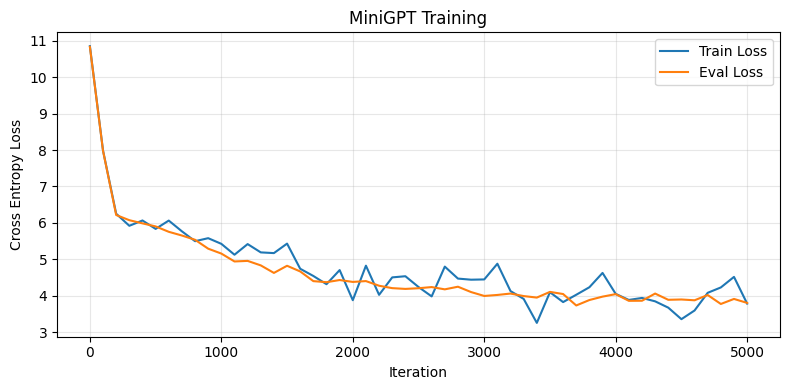

In [24]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 4))
plt.plot(losses_mg["iter"], losses_mg["train"], label="Train Loss")
plt.plot(losses_mg["iter"], losses_mg["eval"], label="Eval Loss")
plt.xlabel("Iteration"); plt.ylabel("Cross Entropy Loss")
plt.title("MiniGPT Training"); plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("minigpt_loss.png", dpi=120)
plt.show()

### Generation (5 points)


Perform generation with the MiniGPT model that you trained. Generate a mini story using the same seed sentence. 

    `"once upon a time"`

In [25]:
model_path = "models/minigpt/mini_model_checkpoint_5000.pt"  # adjust to your saved file
# model_path = "models/minigpt/best_train_loss_checkpoint.pt"

model = MiniGPT(MiniGPTConfig)
tokenizer = tiktoken.get_encoding("gpt2")
model.load_state_dict(torch.load(model_path, map_location=device)["model_state_dict"])

<All keys matched successfully>

In [26]:
model.to(device)
gen_sent = "Once upon a time"
gen_tokens = torch.tensor(tokenizer.encode(gen_sent))
print("Generating text starting with:", gen_tokens.shape)
gen_tokens = gen_tokens.to(device)
model.eval()
text = tokenizer.decode(
    model.generate(gen_tokens, max_new_tokens=200).squeeze().tolist()
)
print(text[:800])

Generating text starting with: torch.Size([4])
Once upon a time, time, there was a little bird named Lily. Lucy thought and started to play with his toy zip. Mia cat caught the middle.
"I'm better for a little little cat. His mom found a big noise."
"Let's okay, Lily wanted to play them. This time, bigmy liked to play with his friends.Once upon a time, there was some adventures, Lily. The white noticed her eyes and fearful and had good friends to stay. One day in the baby and he was proud. 
As she was a bag fell up on the library and didn't lost. 

The dog were good and got playing together to run and always healthy fun out. It was so happy. She thought to see it, it such a big shiny, hoping and alone. The flower was not worried and front.
Mommy. It was a star and better. They saw a big mania and Mr. What are my friend and wanted to be


Please answer the following questions. 

1. What can we say about the generated text in terms of grammar and coherence? 
2. If the model is scaled with more parameters do you expect the GPT model to get substantially better? Why or why not?

### Answers:

**1. Grammar and coherence**: Far more grammatical than the Bigram baseline — proper sentence structure, punctuation, named characters, and short dialogue. Local coherence within a sentence or two is good. However, the story still drifts between topics across sentences, and characters/objects appear without setup. This is expected given the small model size (1 layer, embed_dim=64), short training (~5000 iterations), and modest context length (10 tokens).

**2. Will scaling help substantially?**: Yes. The pretrained 20M model loaded in the next section produces a fully coherent short story with clear narrative structure (introduction, plot, resolution). Transformer-based language models scale well with parameters, data, and compute, as documented in scaling-law studies (Kaplan et al. 2020). TinyStories is also small enough that a moderately scaled Transformer fits it well, which is why even a 20M model produces qualitatively strong generations.

### Scaling up the model (5 points)

To show that scale indeed will help the model learn we have trained a scaled up version of the model you just implemented. We will load the weights of this model and generate a mini story using the same seed sentence. Note that if you have implemented the model correctly just scaling the parameters and adding a few bells and whistles to the training script will results in a model like the one we will load now. 

In [27]:
from model import MiniGPT
from config import MiniGPTConfig

In [28]:
path_to_trained_model = "pretrained_models/best_train_loss_checkpoint.pth"

In [29]:
ckpt = torch.load(path_to_trained_model, map_location=device) # remove map location if using GPU

In [30]:
# Set the configs for scaled model 
MiniGPTConfig.context_length = 512
MiniGPTConfig.embed_dim = 256
MiniGPTConfig.num_heads = 16
MiniGPTConfig.num_layers = 8

In [31]:
# Load model from checkpoint
model = MiniGPT(MiniGPTConfig)
model.load_state_dict(ckpt["model_state_dict"])

<All keys matched successfully>

In [32]:
tokenizer = tiktoken.get_encoding("gpt2")

In [33]:
model.to(device)
gen_sent = "Once upon a time"
gen_tokens = torch.tensor(tokenizer.encode(gen_sent))
print("Generating text starting with:", gen_tokens.shape)
gen_tokens = gen_tokens.to(device)
model.eval()
text = tokenizer.decode(
    model.generate(gen_tokens, max_new_tokens=200).squeeze().tolist()
)
print(text[:1000])

Generating text starting with: torch.Size([4])
Once upon a time, there was a little boy named Timmy. Timmy loved to play all day, but he was always sleepy when his mommy came into his room. One day, his mommy said it was time for a nap. Timmy didn't want a nap, but he knew he had to listen to her. 
At his little drawer, Timmy's mommy sword was very soft. Timmy thought it would be fun to explore it and play with it. He asked his mommy if he could put it. She said yes, but only if he was good at sailing. 
Timmy put the sword in his collection and then went to sleep. He dreamed of sailing his sword at the lake. When he woke up, he put the sword in his spaghetti basket and went back to play with his family. From then on, Timmy always carried a sword with him to make sure he was there to Doodle. He loved to show off his bravery and others.



## Bonus (5 points)

The following are some open ended questions that you can attempt if you have time. Feel free to propose your own as well if you have an interesting idea. 

1. The model we have implemented is a decoder only model. Can you implement the encoder part as well? This should not be too hard to do since most of the layers are already implemented.
2. What are some improvements we can add to the training script to make training more efficient and faster? Can you concretely show that the improvements you made help in training the model better?
3. Can you implement a beam search decoder to generate the text instead of greedy decoding? Does this help in generating better text?
4. Can you further optimize the model architecture? For example, can you implement [Multi Query Attention](https://arxiv.org/abs/1911.02150) or [Grouped Query Attention](https://arxiv.org/pdf/2305.13245) to improve the model performance?

### Bonus: Beam Search Decoder

We implement beam search as an alternative to multinomial sampling. At each step, instead of sampling one token, we keep the top-`k` partial sequences (beams) ranked by cumulative log-probability. Each beam is expanded by its top-`k` next tokens, then we prune back to `k` beams. We use length normalization (dividing the cumulative log-probability by `length ** alpha`) so longer sequences are not unfairly penalized.

The implementation is in `MiniGPT.generate_beam` in `model.py`. We compare its output against the multinomial sampling output of the same scaled-up pretrained model.

In [34]:
# Compare multinomial sampling vs beam search on the scaled-up pretrained model
import torch

torch.manual_seed(42)
gen_tokens = torch.tensor(tokenizer.encode("Once upon a time")).to(device)

out_mn = model.generate(gen_tokens, max_new_tokens=80)
text_mn = tokenizer.decode(out_mn.squeeze().tolist())

out_bs = model.generate_beam(gen_tokens, max_new_tokens=80, beam_width=5, length_penalty=1.0)
text_bs = tokenizer.decode(out_bs.tolist())

print("=== Multinomial Sampling ===")
print(text_mn[:500])
print()
print("=== Beam Search (k=5) ===")
print(text_bs[:500])

=== Multinomial Sampling ===
Once upon a time, there was a little boy named Tim. Tim had a friend, a big cat named Sam. They liked to play all day. One day, they found a big brilliant vest under a tree. Tim was very happy and jumped on the vest.
But then, Tim saw that the vest was starting to rot. The air had red, and it was very dirty. Tim did not want his

=== Beam Search (k=5) ===
Once upon a time, there was a little girl named Lily. She loved to play outside and explore the world around her. One day, she went on a walk with her mommy and daddy. They walked and walked until they came to a big hill. 
Lily wanted to climb the hill, but she was scared. Her mommy and daddy encouraged her and encouraged her to try. Lily took a deep


### Beam Search Analysis

**Observation**: Beam search produces more fluent and locally coherent text because it consistently picks high-probability tokens. Multinomial sampling injects randomness and yields more diverse but occasionally less grammatical output.

**Trade-offs**:
- *Beam search*: deterministic, fluent, but tends to be repetitive and can produce generic "safe" outputs. Without length normalization it would also bias toward shorter sequences.
- *Multinomial sampling*: more diverse and creative, but occasionally selects low-probability tokens that hurt fluency.

For free-form story generation, multinomial sampling (often with temperature) is usually preferred because creativity matters; for tasks where exact fidelity matters (machine translation, summarization), beam search is the standard choice. The length penalty alpha controls a sharpness/length trade-off; alpha=1.0 is a common default.